In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go
import seaborn as sns
import scripts as scr

colors = [
    "#4F81BD",
    "#6FA3D8",
    "#A9CFFF",
    "#93C4EA",
    "#BBDDF5",
    "#CFE8FF",
]
bg_color = "#eff2ff"
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

with open('../data/clean/eda_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [4]:
df_funnel = pd.DataFrame(data['funnel_chart'])
df_sources = pd.DataFrame(data['sources_traffic'])
df_pages = pd.DataFrame(data['pages_distribution'])
df_hours = pd.DataFrame(data['traffic_by_hour'])
df_device = pd.DataFrame(data['device_distribution'])

In [5]:
# === Data Pipeline Funnel ===
# Визуализируем, как данные проходят через этапы обработки
# и где происходят основные потери (очистка, фильтрация, качество)

# Этапы пайплайна — логическая последовательность трансформации данных
stages = [
    "Raw Events",
    "Deduped",
    "Filtered",
    "Low Quality",
    "Medium Quality",
    "High Quality"
]

# Извлекаем значения для каждого этапа воронки
# Важно: используем source/target, чтобы корректно восстановить поток данных
values = [
    df_funnel.loc[df_funnel['source'] == 'raw', 'value'].values[0],         # все события
    df_funnel.loc[df_funnel['target'] == 'dedup', 'value'].values[0],       # после удаления дублей
    df_funnel.loc[df_funnel['target'] == 'filtered', 'value'].values[0],    # после фильтрации мусора
    df_funnel.loc[df_funnel['target'] == 'quality_1', 'value'].values[0],   # низкое качество
    df_funnel.loc[df_funnel['target'] == 'quality_2', 'value'].values[0],   # среднее качество
    df_funnel.loc[df_funnel['target'] == 'quality_3', 'value'].values[0],   # высокое качество
]

# Строим funnel chart, чтобы наглядно показать:
# 1. сколько данных теряется на каждом этапе
# 2. как распределяется трафик по качеству на финальном шаге
fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial",  # показываем абсолютные значения + % от исходного объема
    marker=dict(
        color=colors,  # единая цветовая палитра для визуальной консистентности
        line=dict(
            color="rgba(60, 90, 140, 0.6)",  # легкий контур для лучшей читаемости
            width=1.5
        )
    )
))

# Настройка внешнего вида графика (ориентир на читаемость и аккуратность)
fig.update_layout(
    title=dict(
        text="Data Pipeline Funnel and Quality Distribution",
        x=0.5,
        xanchor="center"
    ),

    width=900,
    height=550,

    # Разделяем фон области графика и всей фигуры
    paper_bgcolor="#fffdfe",
    plot_bgcolor=bg_color,

    margin=dict(l=40, r=40, t=60, b=40),

    # Добавляем рамку — визуально делает график “законченным”
    shapes=[
        dict(
            type="rect",
            xref="paper",
            yref="paper",
            x0=0,
            y0=0,
            x1=1,
            y1=1,
            line=dict(
                color="black",
                width=1
            ),
            fillcolor="rgba(0,0,0,0)"
        )
    ]
)

# Сохраняем график в высоком качестве для использования в отчёте / портфолио
fig.write_image(
    "../charts/data_transformation_funnel.png",
    width=900,
    height=550,
    scale=2
)

fig.show()


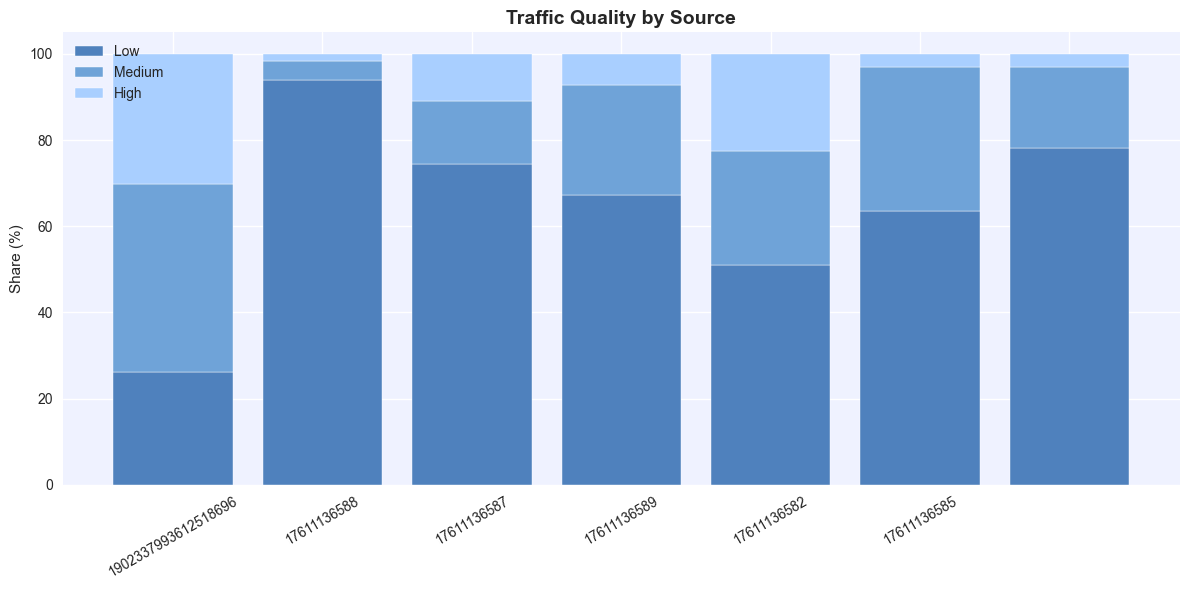

In [6]:
# Цветовая схема качества трафика (единая для всех графиков проекта)
quality = {
    "low": colors[0],
    "medium": colors[1],
    "high": colors[2]
}

# Используем базовый стиль seaborn для аккуратной визуализации
plt.style.use('seaborn-v0_8')

# Фильтруем только значимые источники:
# убираем шум (маленькие источники) и оставляем топ по объему сессий
df_plot = df_sources[df_sources['users'] > 20] \
    .sort_values('sessions', ascending=False) \
    .head(7)

# Создаём фигуру и ось для более гибкого управления графиком
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot()

# Кастомный фон области графика
ax.set_facecolor(bg_color)

# Строим stacked bar chart, чтобы показать:
# 1. вклад каждого источника в общий трафик
# 2. структуру качества внутри источника

# Низкое качество — базовый слой
ax.bar(
    df_plot['ad_placement'],
    df_plot['weak_share'],
    label='Low',
    color=quality["low"]
)

# Среднее качество — накладывается поверх low
ax.bar(
    df_plot['ad_placement'],
    df_plot['medium_share'],
    bottom=df_plot['weak_share'],
    label='Medium',
    color=quality["medium"]
)

# Высокое качество — верхний слой
ax.bar(
    df_plot['ad_placement'],
    df_plot['strong_share'],
    bottom=df_plot['weak_share'] + df_plot['medium_share'],
    label='High',
    color=quality["high"]
)

# Поворачиваем подписи источников для читаемости
plt.xticks(rotation=30)

# Подписи осей и заголовок (ориентир на бизнес-смысл)
ax.set_ylabel('Share (%)')
ax.set_title('Traffic Quality by Source', fontsize=14, weight='bold')

# Легенда — чтобы интерпретировать уровни качества
ax.legend()

# Оптимизация отступов (чтобы ничего не обрезалось)
plt.tight_layout()

# Сохраняем график для отчёта / портфолио
plt.savefig('../charts/traffic_quality_sources.png', dpi=300)
plt.show()


In [7]:
# Группируем страницы по этапам пользовательского пути
# (landing - catalog - car_page)
df_pages['page_group'] = df_pages['page_path'].apply(scr.page_group)

# Конвертируем доли качества в абсолютные значения,
# чтобы корректно агрегировать по группам (нельзя усреднять проценты)
df_pages['low_abs'] = df_pages['sessions'] * df_pages['weak_share'] / 100
df_pages['medium_abs'] = df_pages['sessions'] * df_pages['medium_share'] / 100
df_pages['high_abs'] = df_pages['sessions'] * df_pages['strong_share'] / 100


# Агрегируем по этапам воронки:
# получаем общий объём трафика и распределение качества на каждом шаге
funnel_pages_df = df_pages.groupby('page_group').agg(
    sessions=('sessions', 'sum'),
    low=('low_abs', 'sum'),
    medium=('medium_abs', 'sum'),
    high=('high_abs', 'sum')
).reset_index()

# Явно задаём порядок этапов,
# чтобы сохранить корректную последовательность пользовательского пути
order = ['landing', 'catalog', 'car_page']
funnel_pages_df['page_group'] = pd.Categorical(funnel_pages_df['page_group'], categories=order, ordered=True)
funnel_pages_df = funnel_pages_df.sort_values('page_group')


# Подготавливаем подписи для графика (читаемый формат)
stages = funnel_pages_df['page_group'].map({
    'landing': 'Landing',
    'catalog': 'Catalog',
    'car_page': 'Car page'
}).tolist()

# Общее количество сессий на каждом этапе
sessions = funnel_pages_df['sessions'].tolist()


# Рассчитываем отток пользователей между этапами воронки
drop_texts = [""]

for i in range(1, len(sessions)):
    drop = 1 - sessions[i] / sessions[i-1]
    drop_texts.append(f"Drop-off: {drop:.1%}")

# --- ГРАФИК ---
fig = go.Figure()

# Строим stacked bar chart, чтобы одновременно показать:
# 1. объём трафика на каждом этапе
# 2. структуру качества внутри этапа

# Низкое качество
fig.add_trace(go.Bar(
    y=stages,
    x=funnel_pages_df['low'],
    name="Low",
    orientation='h',
    marker=dict(color="#4F81BD")
))

# Среднее качество
fig.add_trace(go.Bar(
    y=stages,
    x=funnel_pages_df['medium'],
    name="Medium",
    orientation='h',
    marker=dict(color="#93C4EA")
))

# Высокое качество
fig.add_trace(go.Bar(
    y=stages,
    x=funnel_pages_df['high'],
    name="High",
    orientation='h',
    marker=dict(color="#CFE8FF")
))


# Ручная настройка аннотаций:
# смещаем текст drop-off, чтобы он не перекрывался с барами
for i in range(1, len(stages)):

    if i == 1:
        x_pos = sessions[i-1] * 0.26
    else:
        x_pos = sessions[i-1] * 0.8
    fig.add_annotation(
        x=x_pos,
        y=stages[i],
        text=drop_texts[i],
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-30
    )

# --- LAYOUT ---
fig.update_layout(
    barmode='stack',

    title=dict(
        text="User Funnel with Quality Distribution",
        x=0.5
    ),

    xaxis_title="Sessions",

    # Переворачиваем ось, чтобы funnel читался сверху вниз
    yaxis=dict(autorange="reversed"),

    width=900,
    height=500,

    # Кастомный фон
    plot_bgcolor=bg_color,
    paper_bgcolor="#fffdfe",

    margin=dict(l=40, r=40, t=60, b=40),

    # Легенда сверху — не мешает восприятию данных
    legend=dict(
        orientation="h",
        y=1.077,
        x=0.5,
        xanchor="center"
    )
)

# Сохраняем график для отчёта / портфолио
fig.write_image(
    "../charts/funnel_landing_catalog_car.png",
    width=900,
    height=550,
    scale=2
)

fig.show()

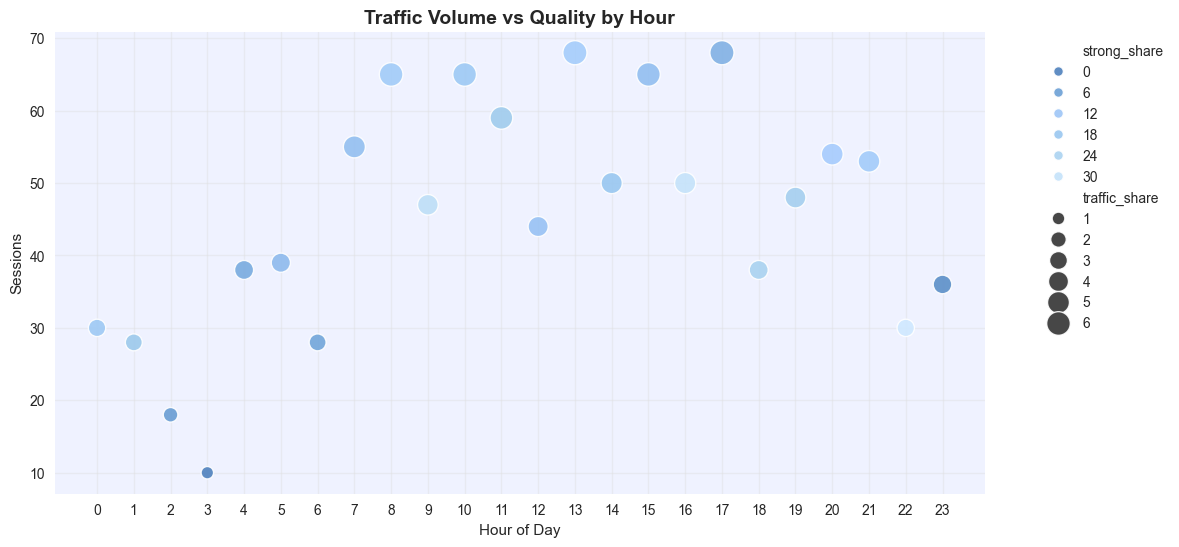

In [8]:
plt.figure(figsize=(12,6))

# Scatter plot:
# X — час дня
# Y — количество сессий (объём трафика)
# hue — доля качественного трафика (strong_share)
# size — вклад часа в общий трафик (traffic_share)
sns.scatterplot(
    data=df_hours,
    x='hour',
    y='sessions',
    hue='strong_share',
    size='traffic_share',
    palette=custom_cmap,
    sizes=(80, 300),
    alpha=0.9,
    legend=True
)

plt.xticks(range(0, 24))

plt.grid(True, alpha=0.4, color='#dddddd')

plt.gca().set_facecolor(bg_color)

plt.title('Traffic Volume vs Quality by Hour', fontsize=14, weight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Sessions')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('../charts/hour_quality_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Переводим доли качества в абсолютные значения,
# чтобы корректно сравнивать устройства по объему и структуре трафика
df_device['low_abs'] = df_device['sessions'] * df_device['low_share'] / 100
df_device['medium_abs'] = df_device['sessions'] * df_device['medium_share'] / 100
df_device['high_abs'] = df_device['sessions'] * df_device['high_share'] / 100

# Типы устройств (например: mobile, desktop, tablet)
stages = df_device['screen_group'].tolist()

# Общее количество сессий по устройствам
sessions = df_device['sessions'].tolist()

# --- ГРАФИК ---
fig = go.Figure()

# Строим stacked bar chart, чтобы показать:
# 1. вклад каждого устройства в общий трафик
# 2. распределение качества внутри каждого устройства

# Низкое качество
fig.add_trace(go.Bar(
    y=stages,
    x=df_device['low_abs'],
    name="Low",
    orientation='h',
    marker=dict(color="#4F81BD")
))

# Среднее качество
fig.add_trace(go.Bar(
    y=stages,
    x=df_device['medium_abs'],
    name="Medium",
    orientation='h',
    marker=dict(color="#93C4EA")
))

# Высокое качество
fig.add_trace(go.Bar(
    y=stages,
    x=df_device['high_abs'],
    name="High",
    orientation='h',
    marker=dict(color="#CFE8FF")
))

fig.update_layout(
    barmode='stack',

    title=dict(
        text="Traffic Quality Distribution by Device",
        x=0.5,
        font=dict(size=20)
    ),

    xaxis_title="Sessions",

    # Переворачиваем ось для удобного чтения сверху вниз
    yaxis=dict(autorange="reversed"),

    width=900,
    height=500,

    # Кастомный фон
    plot_bgcolor=bg_color,
    paper_bgcolor="#fffdfe",

    # Легенда сверху — не перекрывает график
    legend=dict(
        orientation="h",
        y=1.073,
        x=0.47,
        xanchor="center"
    ),

    margin=dict(l=40, r=40, t=60, b=40)
)

# Сохраняем график для отчёта / портфолио
fig.write_image(
    "../charts/device_quality.png",
    width=900,
    height=550,
    scale=2
)

fig.show()

